In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/home/social_media_productivity_6000.csv')

In [ ]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [ ]:
df = pd.read_csv('/home/social_media_productivity_6000.csv',usecols=['age','daily_screen_time','social_media_hours','productivity_score'])

In [ ]:
df

,age,daily_screen_time,social_media_hours,productivity_score
0,21.0,5.95,2.81,28.49
1,34.0,3.82,2.33,18.54
2,29.0,3.57,1.64,68.52
3,25.0,10.27,4.37,27.82
4,22.0,2.42,1.60,51.09
...,...,...,...,...
5995,20.0,2.05,0.71,84.55
5996,28.0,6.28,4.90,37.63
5997,19.0,3.97,3.40,6.67
5998,30.0,11.11,9.16,0.00


In [ ]:
##df = pd.read_csv('/home/calorie_efficiency_dataset.csv',usecols=['age','workouts_per_week','heart_rate_avg','efficiency_score','calorie_efficiency'])

In [ ]:
#df

In [ ]:
df.shape

(6000, 4)

In [ ]:
df.isnull().sum()

,0
age,120
daily_screen_time,120
social_media_hours,120
productivity_score,120


In [ ]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

,0
age,2.0
daily_screen_time,2.0
social_media_hours,2.0
productivity_score,2.0


In [ ]:
df = df.dropna()

In [ ]:
df

,age,daily_screen_time,social_media_hours,productivity_score
0,21.0,5.95,2.81,28.49
1,34.0,3.82,2.33,18.54
2,29.0,3.57,1.64,68.52
3,25.0,10.27,4.37,27.82
4,22.0,2.42,1.60,51.09
...,...,...,...,...
5995,20.0,2.05,0.71,84.55
5996,28.0,6.28,4.90,37.63
5997,19.0,3.97,3.40,6.67
5998,30.0,11.11,9.16,0.00


In [ ]:
df.isnull().sum()

,0
age,0
daily_screen_time,0
social_media_hours,0
productivity_score,0


In [ ]:
df.describe()

,age,daily_screen_time,social_media_hours,productivity_score
count,5532.000000,5532.000000,5532.000000,5532.000000
mean,27.165040,6.934644,4.152977,37.666303
std,7.264737,2.863060,2.158085,27.706930
min,15.000000,2.000000,0.660000,0.000000
25%,21.000000,4.470000,2.400000,13.535000
50%,27.000000,6.895000,3.760000,36.130000
75%,34.000000,9.390000,5.550000,58.770000
max,39.000000,11.990000,10.660000,100.000000


In [ ]:
X = df.iloc[:,0:3]
y = df.iloc[:,3:]

In [ ]:
X

,age,daily_screen_time,social_media_hours
0,21.0,5.95,2.81
1,34.0,3.82,2.33
2,29.0,3.57,1.64
3,25.0,10.27,4.37
4,22.0,2.42,1.60
...,...,...,...
5995,20.0,2.05,0.71
5996,28.0,6.28,4.90
5997,19.0,3.97,3.40
5998,30.0,11.11,9.16


In [ ]:
y

,productivity_score
0,28.49
1,18.54
2,68.52
3,27.82
4,51.09
...,...
5995,84.55
5996,37.63
5997,6.67
5998,0.00


In [ ]:
#from sklearn.preprocessing import OrdinalEncoder

#enc = OrdinalEncoder()
#y.loc[:, 'calorie_efficiency'] = enc.fit_transform(y[['calorie_efficiency']])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

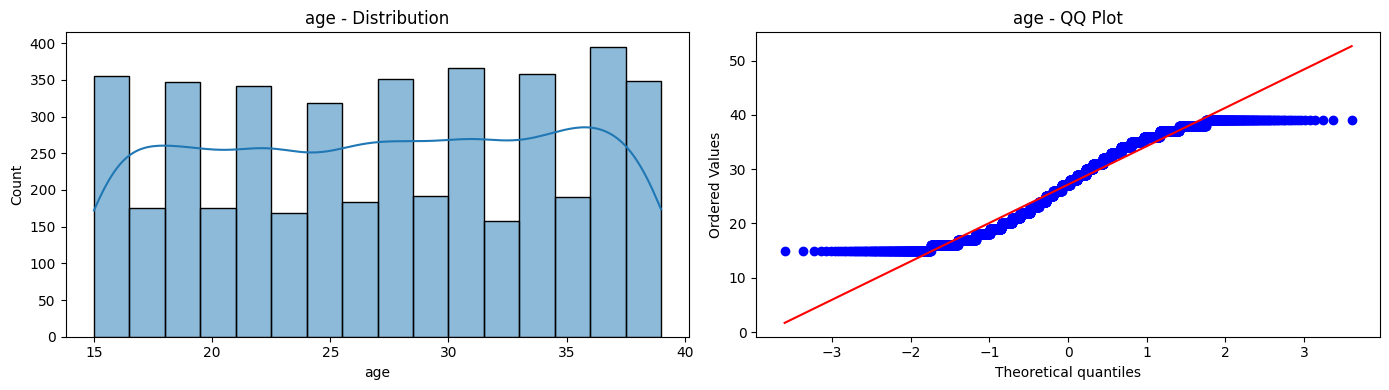

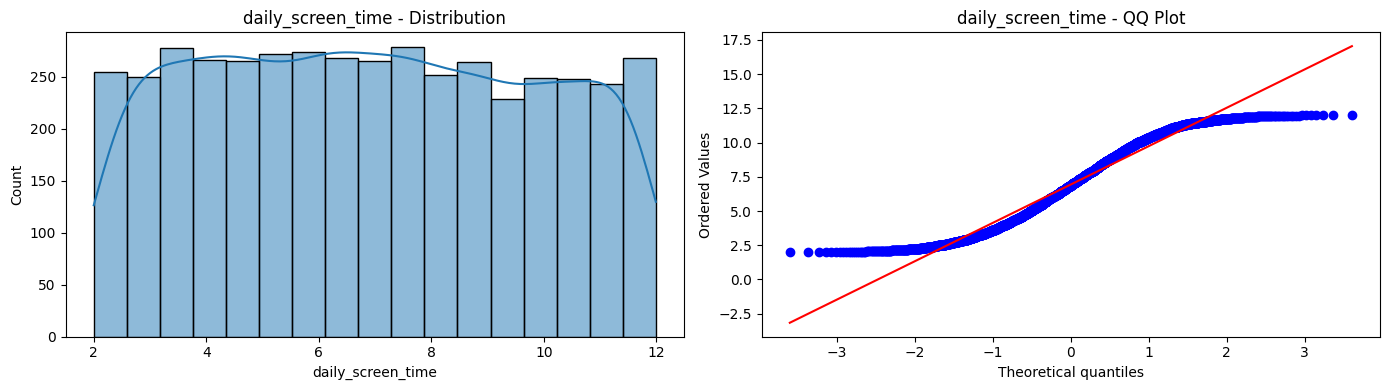

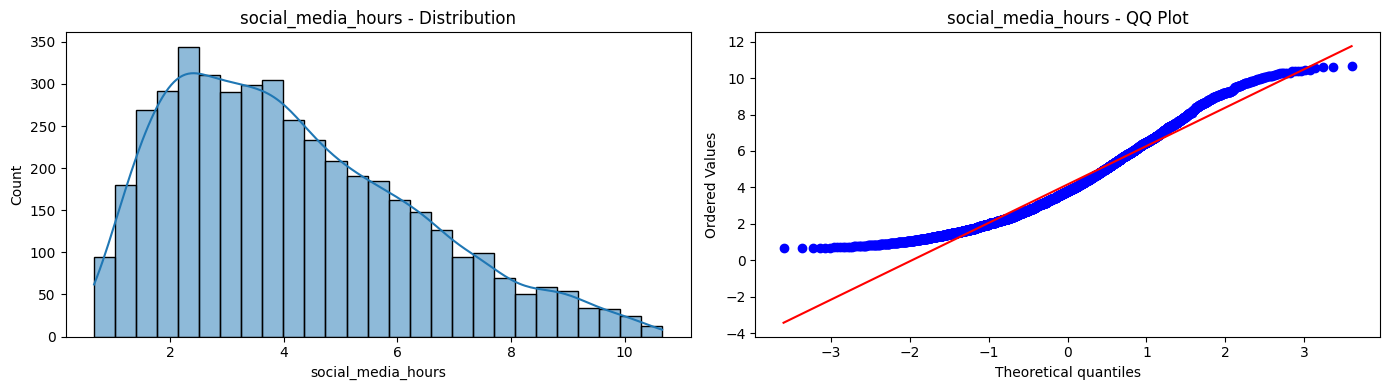

In [ ]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))

    # Drop NaN values
    data = X_train[col].dropna()

    # Histogram + KDE
    plt.subplot(121)
    sns.histplot(data, kde=True)
    plt.title(f"{col} - Distribution")

    # QQ Plot
    plt.subplot(122)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"{col} - QQ Plot")

    plt.tight_layout()
    plt.show()

In [ ]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,age,0.833465
1,daily_screen_time,0.701049
2,social_media_hours,0.306472


In [ ]:
# Applying linear regression on transformed data

lr = LinearRegression()

lr.fit(X_train_transformed,y_train)

y_pred = lr.predict(X_test_transformed)

r2_score(y_test,y_pred)

0.2529126686240274

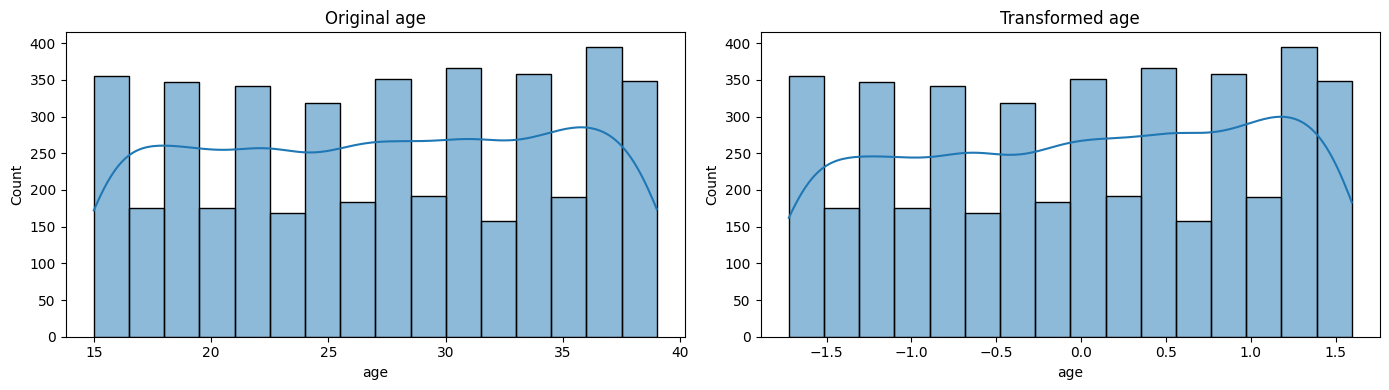

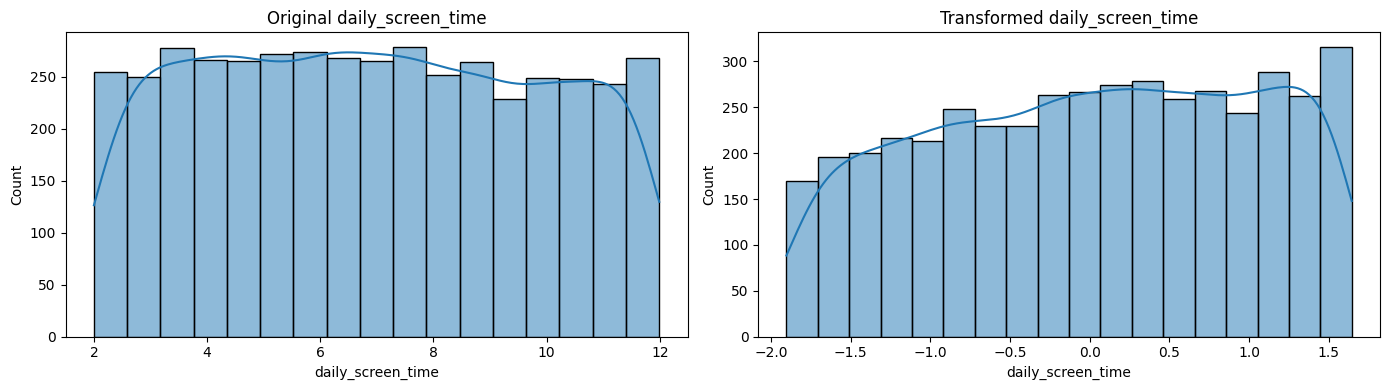

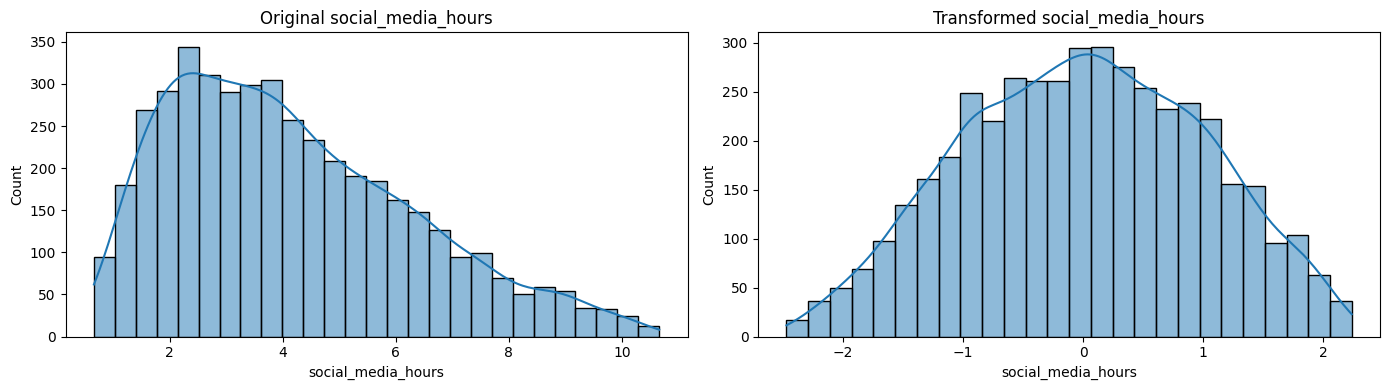

In [ ]:
# Before and after comparision for Box-Cox Plot

X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)

for col in X_train.columns:
    plt.figure(figsize=(14,4))

    # Original Data
    plt.subplot(121)
    sns.histplot(X_train[col].dropna(), kde=True)
    plt.title(f"Original {col}")

    # Transformed Data
    plt.subplot(122)
    sns.histplot(X_train_transformed[col].dropna(), kde=True)
    plt.title(f"Transformed {col}")

    plt.tight_layout()
    plt.show()

In [ ]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train)
X_test_transformed2 = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.253107778762227


,cols,Yeo_Johnson_lambdas
0,age,0.837626
1,daily_screen_time,0.692801
2,social_media_hours,0.123046


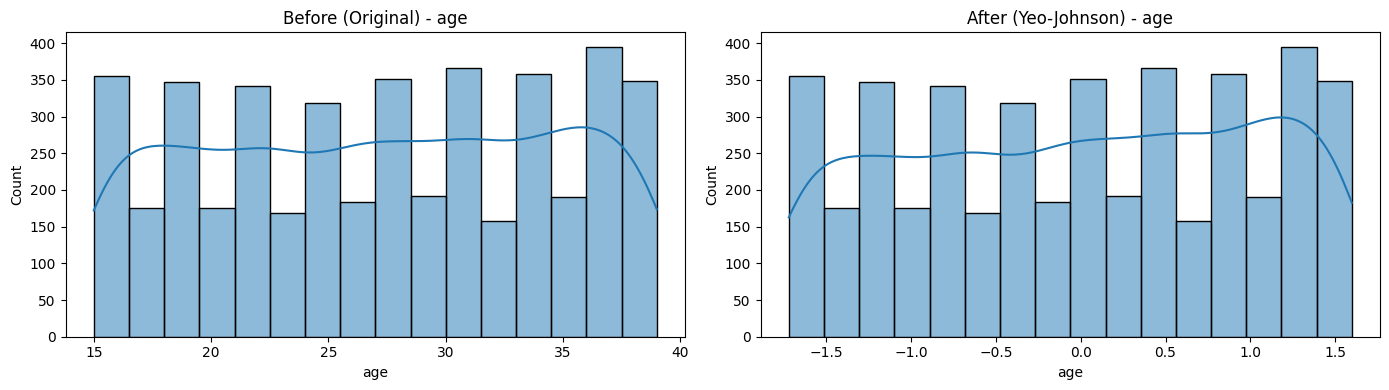

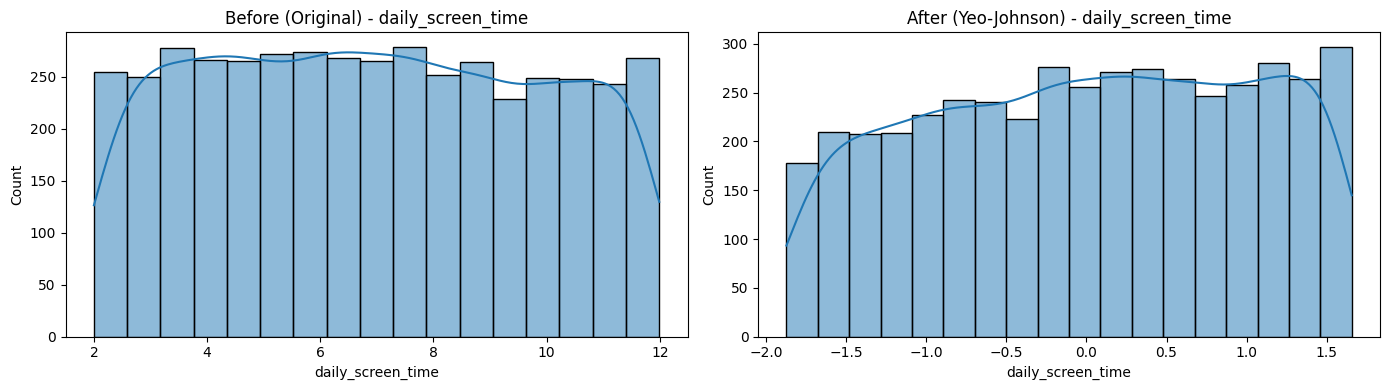

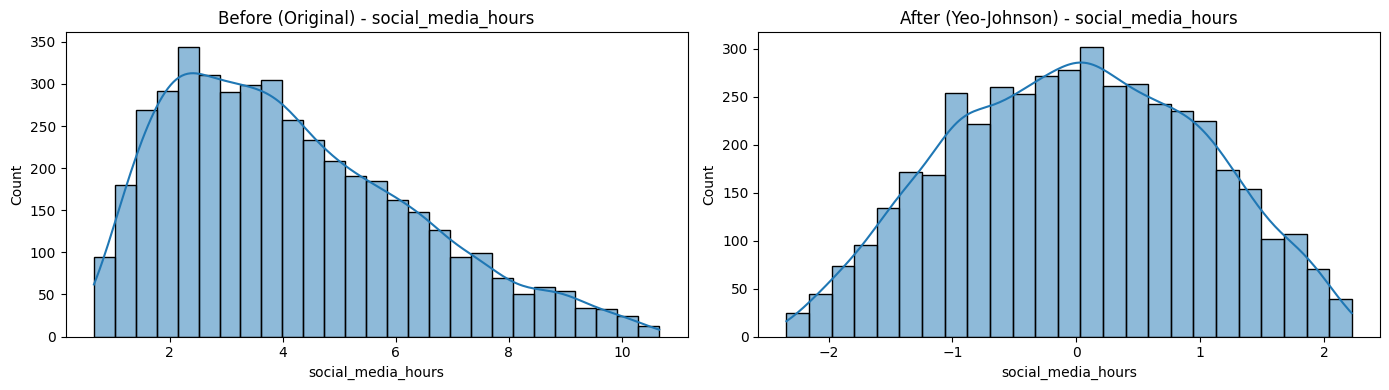

In [ ]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=X_train.columns)
for col in X_train.columns:
    plt.figure(figsize=(14,4))

    # Before (Original)
    plt.subplot(121)
    sns.histplot(X_train[col].dropna(), kde=True)
    plt.title(f"Before (Original) - {col}")

    # After (Yeo-Johnson)
    plt.subplot(122)
    sns.histplot(X_train_transformed2[col], kde=True)
    plt.title(f"After (Yeo-Johnson) - {col}")

    plt.tight_layout()
    plt.show()